# 03 · Clasificación: exposición a la *Gas Guzzler Tax*

La *Gas Guzzler Tax* (EE. UU.) grava los **turismos** cuyo consumo combinado no ajustado es inferior a 22,5 mpg;
los vehículos que la NHTSA clasifica como camiones (SUV grandes, pick-ups) están exentos.

**Pregunta de negocio:** ¿se puede anticipar si una configuración pagará la tasa **antes de homologarla**, es decir,
sin conocer su consumo? Es una señal temprana útil en la definición de gama y en la planificación de producto.

## Protocolo

| Elemento | Decisión |
|---|---|
| Desequilibrio | 55 positivos de 964 (5,7 %) → particiones **estratificadas**, métricas de la clase positiva (precisión, recall, F1, PR-AUC) |
| Fuga entre variantes | Particiones **agrupadas por familia de modelo** (`StratifiedGroupKFold`) |
| Selección de hiperparámetros | Sólo con datos de entrenamiento, optimizando F1 |
| Estabilidad | Validación cruzada repetida (3 semillas × 5 particiones) |
| Referencias | Clase mayoritaria y regla experta basada en el motor |

In [1]:
try:
    import vehicle_emissions  # instalado con `pip install -e .`
except ModuleNotFoundError:  # ejecución directa sin instalar el paquete
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
RANDOM_STATE = 42

In [2]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, average_precision_score,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from vehicle_emissions.data import load_fe_guide
from vehicle_emissions.paths import FIGURES_DIR
from vehicle_emissions.validation import validate_fe_guide

df = load_fe_guide()
validate_fe_guide(df)
print(df["Guzzler?"].value_counts().rename({0: "No guzzler", 1: "Guzzler"}).to_string())

Guzzler?
No guzzler    909
Guzzler        55


## 1. Estructura del problema

In [3]:
pd.crosstab(df["Gas Guzzler Exempt"].map({0: "No exento (turismo)", 1: "Exento (camión NHTSA)"}),
            df["Guzzler?"].map({0: "No guzzler", 1: "Guzzler"}), margins=True, margins_name="Total")

Guzzler?,Guzzler,No guzzler,Total
Gas Guzzler Exempt,,,
Exento (camión NHTSA),0,537,537
No exento (turismo),55,372,427
Total,55,909,964


In [4]:
pd.crosstab(df["# Cyl"], df["Guzzler?"].map({0: "No guzzler", 1: "Guzzler"}))

Guzzler?,Guzzler,No guzzler
# Cyl,,
3,0,25
4,0,436
5,0,1
6,12,308
8,24,139
10,3,0
12,15,0
16,1,0


Dos reglas emergen directamente de la normativa y de los datos: **ningún exento paga** y **todos los motores de
10 o más cilindros pagan**. La dificultad está en los turismos de 6 y 8 cilindros, que caen a ambos lados del umbral.

## 2. Variables y partición

In [5]:
NUM = ["Eng Displ", "# Cyl", "# Gears", "Hybrid", "Gas Guzzler Exempt"]
CAT = ["Trans Desc", "Drive Desc", "Fuel Usage", "Carline Class Desc"]
X, y, groups = df[NUM + CAT], df["Guzzler?"], df["Model Family"]

outer = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
idx_tr, idx_te = next(outer.split(X, y, groups))
X_train, X_test, y_train, y_test = X.iloc[idx_tr], X.iloc[idx_te], y.iloc[idx_tr], y.iloc[idx_te]
g_train = groups.iloc[idx_tr]
assert not set(g_train) & set(groups.iloc[idx_te]), "fuga de familias entre train y test"
print(f"Entrenamiento: {len(X_train)} ({y_train.sum()} guzzlers) · Prueba: {len(X_test)} ({y_test.sum()} guzzlers)")
inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metrics(name, y_true, y_pred, y_score=None):
    return {"Modelo": name,
            "Precisión": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred), "F1": f1_score(y_true, y_pred),
            "PR-AUC": average_precision_score(y_true, y_score) if y_score is not None else np.nan}
holdout = []

Entrenamiento: 644 (37 guzzlers) · Prueba: 320 (18 guzzlers)


## 3. Referencias

* **Clase mayoritaria:** predice siempre "no guzzler" (accuracy del 94 %, utilidad nula).
* **Regla experta:** turismo no exento con 8 o más cilindros. Es lo que aplicaría un ingeniero sin modelo.

In [6]:
class ExpertRule(BaseEstimator, ClassifierMixin):
    """Guzzler si el vehículo no está exento y tiene al menos `min_cyl` cilindros."""

    def __init__(self, min_cyl=8):
        self.min_cyl = min_cyl

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return ((X["Gas Guzzler Exempt"] == 0) & (X["# Cyl"] >= self.min_cyl)).astype(int).to_numpy()

    def predict_proba(self, X):
        p = self.predict(X)
        return np.c_[1 - p, p]

for name, est in [("Referencia · clase mayoritaria", DummyClassifier(strategy="most_frequent")),
                  ("Referencia · regla experta (≥ 8 cil., no exento)", ExpertRule())]:
    est.fit(X_train, y_train)
    holdout.append(metrics(name, y_test, est.predict(X_test), est.predict_proba(X_test)[:, 1]))
pd.DataFrame(holdout).set_index("Modelo").round(3)

,Precisión,Recall,F1,PR-AUC
Modelo,,,,
Referencia · clase mayoritaria,0.000,0.000,0.0,0.056
"Referencia · regla experta (≥ 8 cil., no exento)",0.636,0.778,0.7,0.507


## 4. Regresión logística (modelo lineal ponderado)

In [7]:
pre_scaled = ColumnTransformer([("num", StandardScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)])
logit = GridSearchCV(Pipeline([("pre", pre_scaled), ("clf", LogisticRegression(class_weight="balanced", max_iter=5000))]),
                     {"clf__C": [0.01, 0.1, 1, 10]}, cv=inner, scoring="f1")
logit.fit(X_train, y_train, groups=g_train)
best_logit = logit.best_estimator_
print("C =", logit.best_params_["clf__C"])
holdout.append(metrics("Regresión logística", y_test, best_logit.predict(X_test), best_logit.predict_proba(X_test)[:, 1]))

C = 10


## 5. Árbol de decisión

In [8]:
pre_tree = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), CAT)], remainder="passthrough")
tree_search = GridSearchCV(
    Pipeline([("pre", pre_tree), ("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    {"clf__max_depth": [2, 3, 4, 5, 8, None], "clf__min_samples_leaf": [1, 2, 4, 8],
     "clf__criterion": ["gini", "entropy"], "clf__class_weight": [None, "balanced"]},
    cv=inner, scoring="f1", n_jobs=-1)
tree_search.fit(X_train, y_train, groups=g_train)
best_tree = tree_search.best_estimator_
print("Hiperparámetros:", {k.split("__")[1]: v for k, v in tree_search.best_params_.items()})
holdout.append(metrics("Árbol de decisión", y_test, best_tree.predict(X_test), best_tree.predict_proba(X_test)[:, 1]))

Hiperparámetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2}


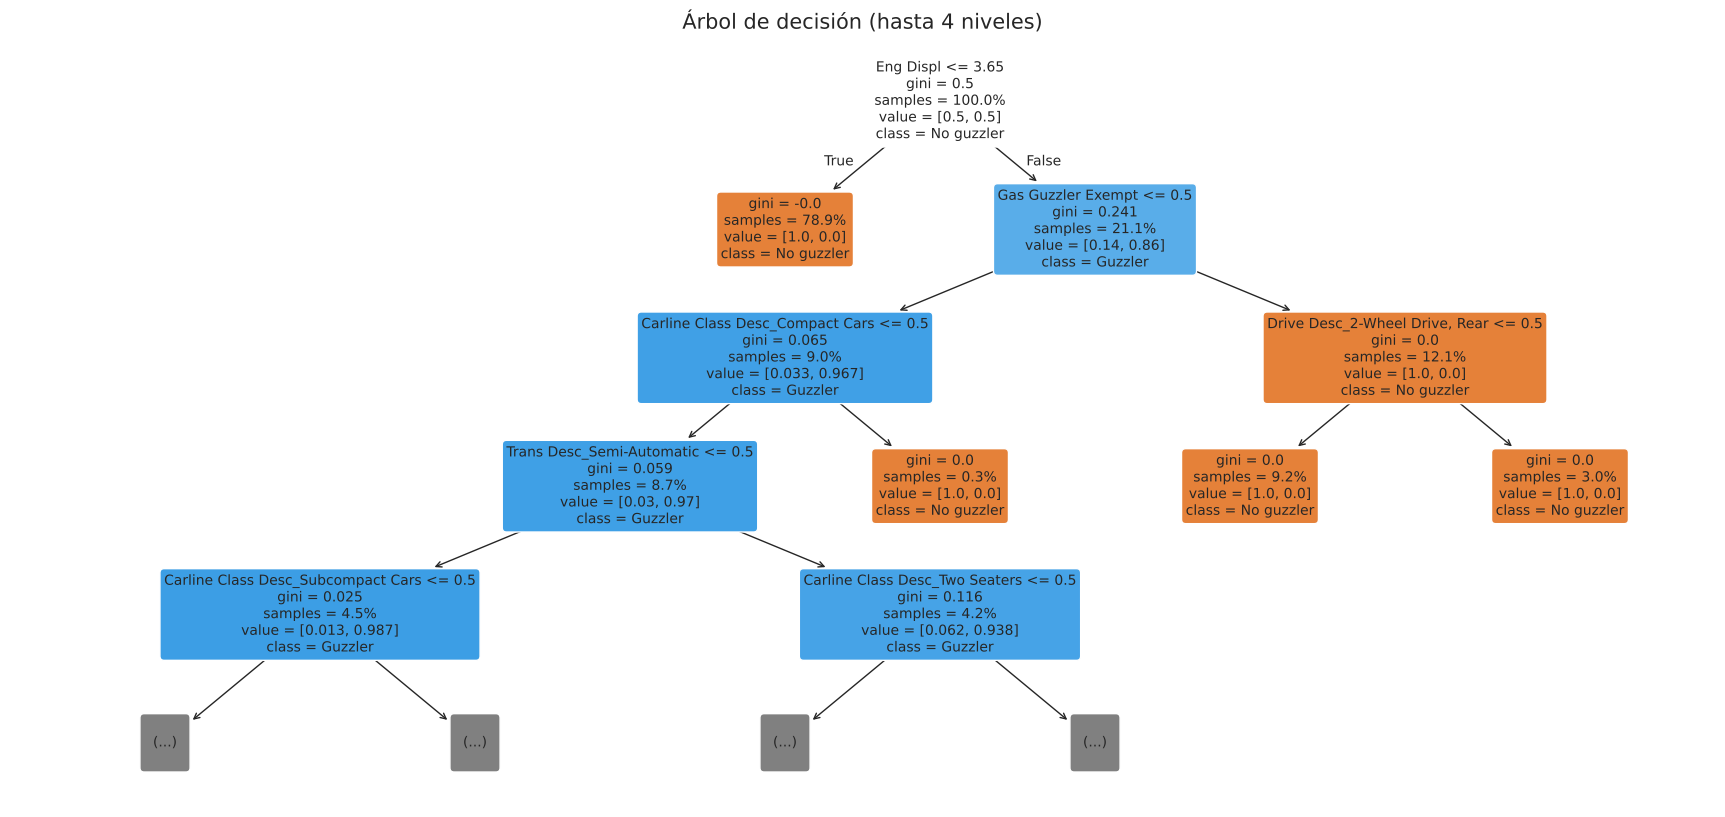

In [9]:
feature_names = [n.split("__", 1)[1] for n in best_tree.named_steps["pre"].get_feature_names_out()]
clf = best_tree.named_steps["clf"]
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(clf, feature_names=feature_names, class_names=["No guzzler", "Guzzler"], filled=True, rounded=True,
          fontsize=10, max_depth=4, proportion=True, ax=ax)
ax.set_title("Árbol de decisión (hasta 4 niveles)", fontsize=15)
fig.savefig(FIGURES_DIR / "03_arbol_decision.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Red neuronal (perceptrón multicapa)

In [10]:
mlp_search = GridSearchCV(
    Pipeline([("pre", pre_scaled), ("clf", MLPClassifier(activation="relu", solver="adam", max_iter=2000,
                                                          random_state=RANDOM_STATE))]),
    {"clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64, 32, 16)], "clf__alpha": [1e-4, 1e-2, 1e-1]},
    cv=inner, scoring="f1", n_jobs=-1)
mlp_search.fit(X_train, y_train, groups=g_train)
best_mlp = mlp_search.best_estimator_
print("Hiperparámetros:", {k.split("__")[1]: v for k, v in mlp_search.best_params_.items()})
holdout.append(metrics("Red neuronal (MLP)", y_test, best_mlp.predict(X_test), best_mlp.predict_proba(X_test)[:, 1]))

Hiperparámetros: {'alpha': 0.01, 'hidden_layer_sizes': (128, 64, 32, 16)}


## 7. Resultados en la partición de prueba

In [11]:
res = pd.DataFrame(holdout).set_index("Modelo").round(3)
res

,Precisión,Recall,F1,PR-AUC
Modelo,,,,
Referencia · clase mayoritaria,0.000,0.000,0.000,0.056
"Referencia · regla experta (≥ 8 cil., no exento)",0.636,0.778,0.700,0.507
Regresión logística,0.552,0.889,0.681,0.816
Árbol de decisión,0.667,0.889,0.762,0.582
Red neuronal (MLP),0.750,0.833,0.789,0.849


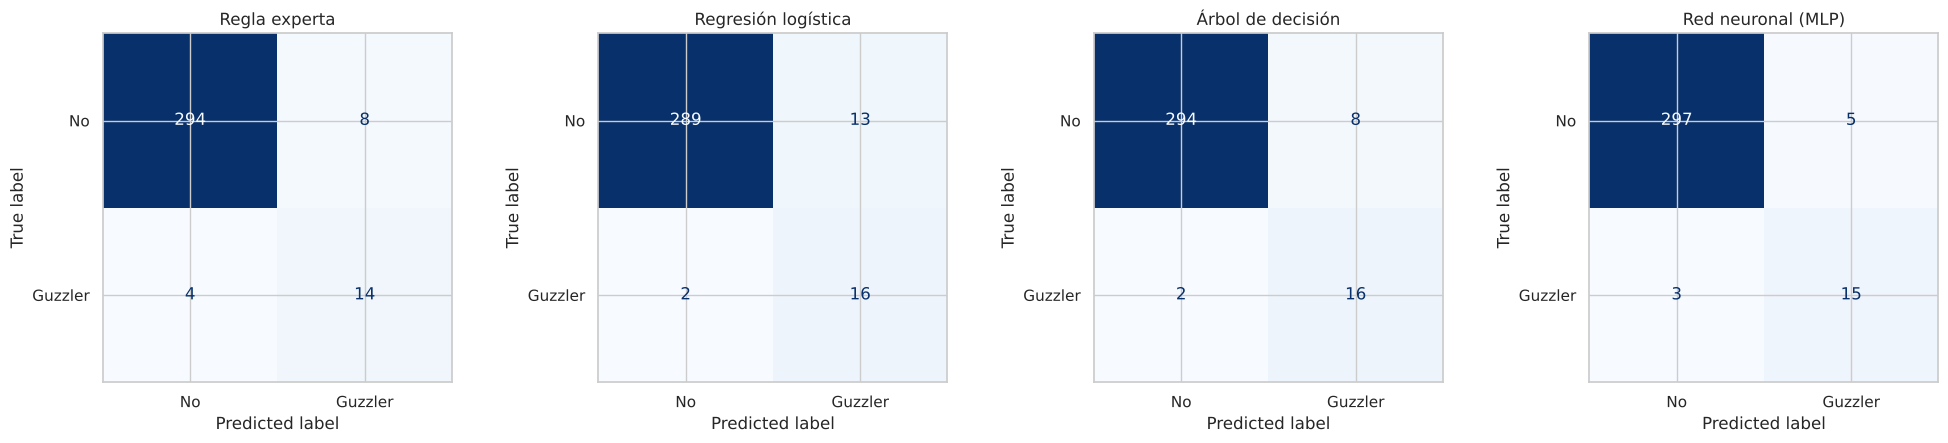

In [12]:
models = {"Regla experta": ExpertRule(), "Regresión logística": best_logit, "Árbol de decisión": best_tree,
          "Red neuronal (MLP)": best_mlp}
fig, axs = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, m) in zip(axs, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, m.predict(X_test), display_labels=["No", "Guzzler"],
                                            cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03_matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

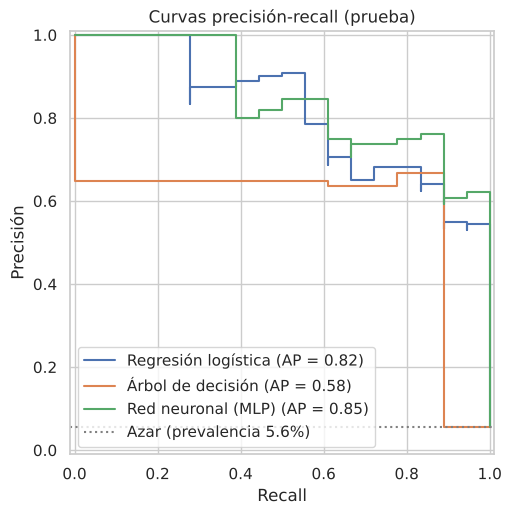

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name, m in list(models.items())[1:]:
    PrecisionRecallDisplay.from_predictions(y_test, m.predict_proba(X_test)[:, 1], name=name, ax=ax)
ax.axhline(y_test.mean(), color="grey", ls=":", label=f"Azar (prevalencia {y_test.mean():.1%})")
ax.set(title="Curvas precisión-recall (prueba)", xlabel="Recall", ylabel="Precisión"); ax.legend(loc="lower left")
fig.savefig(FIGURES_DIR / "03_curvas_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Estabilidad: validación cruzada repetida

Con pocos positivos en prueba, un único hold-out es ruidoso. Se repite una validación cruzada estratificada y
agrupada de 5 particiones con 3 semillas, reajustando cada modelo con sus hiperparámetros seleccionados.

In [14]:
rows = []
for name, m in models.items():
    # la regla experta no produce puntuaciones continuas: no tiene sentido calcular su PR-AUC
    keys = ["F1", "Precisión", "Recall"] + ([] if isinstance(m, ExpertRule) else ["PR-AUC"])
    sc = {"F1": "f1", "Precisión": "precision", "Recall": "recall", "PR-AUC": "average_precision"}
    scores = {k: [] for k in keys}
    for seed in (0, 1, 2):
        cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
        s = cross_validate(clone(m), X, y, groups=groups, cv=cv, scoring={k: sc[k] for k in keys})
        for k in keys:
            scores[k].extend(s[f"test_{k}"])
    rows.append({"Modelo": name, **{f"{k} media": np.mean(v) for k, v in scores.items()},
                 "F1 std": np.std(scores["F1"])})
cv_tab = pd.DataFrame(rows).set_index("Modelo").round(3)
cv_tab

,F1 media,Precisión media,Recall media,F1 std,PR-AUC media
Modelo,,,,,
Regla experta,0.683,0.624,0.777,0.112,NaN
Regresión logística,0.698,0.576,0.908,0.088,0.836
Árbol de decisión,0.773,0.663,0.953,0.106,0.726
Red neuronal (MLP),0.796,0.817,0.811,0.110,0.877


## 9. Análisis de errores

In [15]:
err = df.iloc[idx_te].assign(arbol=best_tree.predict(X_test), mlp=best_mlp.predict(X_test))
err = err[(err["arbol"] != err["Guzzler?"]) | (err["mlp"] != err["Guzzler?"])]
print(f"Vehículos mal clasificados por algún modelo: {len(err)} · "
      f"con consumo no ajustado entre 19 y 26 mpg: {err['Comb Unadj FE'].between(19, 26).mean():.0%}")
err[["Division", "Carline", "Eng Displ", "# Cyl", "Carline Class Desc", "Comb Unadj FE", "Guzzler?", "arbol", "mlp"]
    ].sort_values("Comb Unadj FE")

Vehículos mal clasificados por algún modelo: 14 · con consumo no ajustado entre 19 y 26 mpg: 64%


,Division,Carline,Eng Displ,# Cyl,Carline Class Desc,Comb Unadj FE,Guzzler?,arbol,mlp
7,Chevrolet,CORVETTE Z06 CARBON AERO,5.5,8,Two Seaters,16.9373,1,0,1
6,Chevrolet,CORVETTE Z06,5.5,8,Two Seaters,17.8005,1,0,1
392,MASERATI,Quattroporte Trofeo,3.8,8,Large Cars,20.1400,1,1,0
317,MASERATI,Ghibli Trofeo,3.8,8,Midsize Cars,20.1400,1,1,0
262,Audi,RS 7,4.0,8,Midsize Cars,21.1994,1,1,0
51,Aston Martin Lagonda Ltd,DB12 V8,4.0,8,Minicompact Cars,22.4729,0,1,0
365,Audi,S8,4.0,8,Large Cars,23.5599,0,1,0
150,LEXUS,LC 500,5.0,8,Subcompact Cars,23.8549,0,1,0
4,Chevrolet,CORVETTE,6.2,8,Two Seaters,23.9592,0,0,1
37,Porsche,718 Cayman GTS 4.0,4.0,6,Two Seaters,25.0826,0,1,1


## 10. Conclusiones

* **El problema es casi una regla regulatoria.** Una regla experta trivial (turismo no exento con ≥ 8 cilindros) ya
  alcanza F1 ≈ 0,68 en validación cruzada; cualquier modelo debe justificarse frente a ella, no frente a la accuracy.
* **La red neuronal es el mejor clasificador** (F1 ≈ 0,80 y PR-AUC ≈ 0,88 en CV repetida), con el mejor equilibrio entre
  precisión y recall. El **árbol de decisión** prioriza el recall (≈ 0,95): no se le escapan casi guzzlers, a costa de
  más falsas alarmas, y a cambio es completamente auditable.
* **La variabilidad entre particiones es alta** (desviación de F1 ≈ 0,1) porque sólo hay 55 positivos. Las diferencias
  de pocas centésimas entre modelos no son significativas; la conclusión robusta es *modelo > regla experta > nada*.
* **Los errores se concentran en la frontera regulatoria:** cerca de dos tercios de los vehículos mal clasificados tienen
  un consumo no ajustado entre 19 y 26 mpg, alrededor del umbral de 22,5 mpg. Sin el consumo, la configuración del motor
  no basta para resolver esa franja; es el límite natural de una señal temprana.
* **Uso recomendado:** el árbol como filtro de cribado (alto recall) en fase de definición de producto, y el MLP como
  estimación de probabilidad para priorizar qué configuraciones validar antes en banco.